In [38]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import xarray
sys.path.append("../src/climate_trends/")

import load as ld
import xarray as xr
import pandas as pd
from statsmodels.tsa.seasonal import STL

# Summary

In this notebook, I have analyzed temperature(t2m in degree Celcius) for both Paris and Berlin over last 7 decades (1950-2025). Upon analyzing, we can observe a clear increasing trend when averaging over 1-year periods and more. We then focus on the Paris dataset to study the nature of the trend in more detail.

We apply STL decomposition to remove seasonal effects and isolate the underlying trend. Next we try to Fit a linear model to data from 1980 onward. however, this  reveals systematic structure in the residuals, indicating that a linear trend is insufficient. A quadratic model provides slight improvement, suggesting mild non-linearity.
We also look at the stationarity of the data throgh the ADF and KPSS. This tests indicate that the residuals are not fully stationary, pointing to the fact that using a more flexible approach such as state-space model will better capture the dynamics of the data.

# Load the data [for Berlin and Paris]

In [135]:
ds_b=ld.load_single_file("../data/raw/era5_berlin_t2m.nc")
ds_p=ld.load_single_file("../data/raw/era5_paris_t2m.nc")
t2m_p = ds_p["t2m"].sel(latitude=48.75,longitude=2.25,method='nearest') -273.5
t2m_b = ds_b["t2m"].sel(latitude=52.5,longitude=13.25,method='nearest') -273.5


# Raw plot for Monthly Data

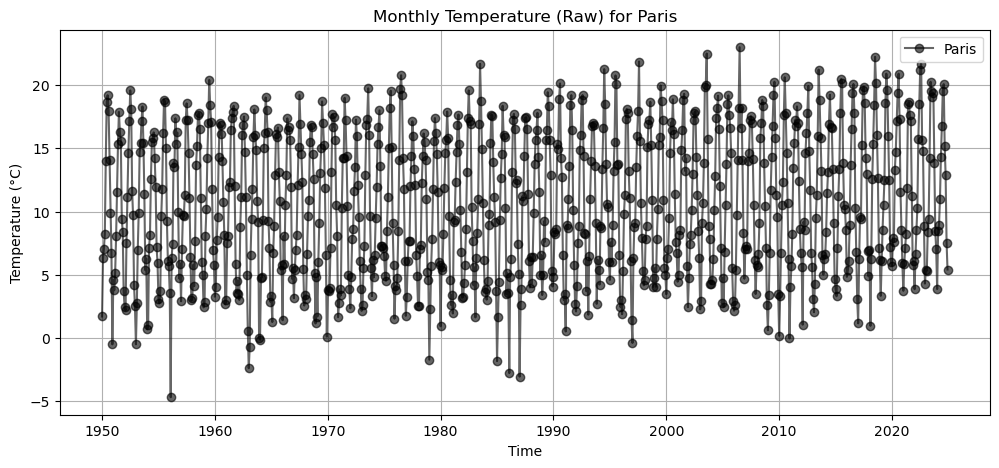

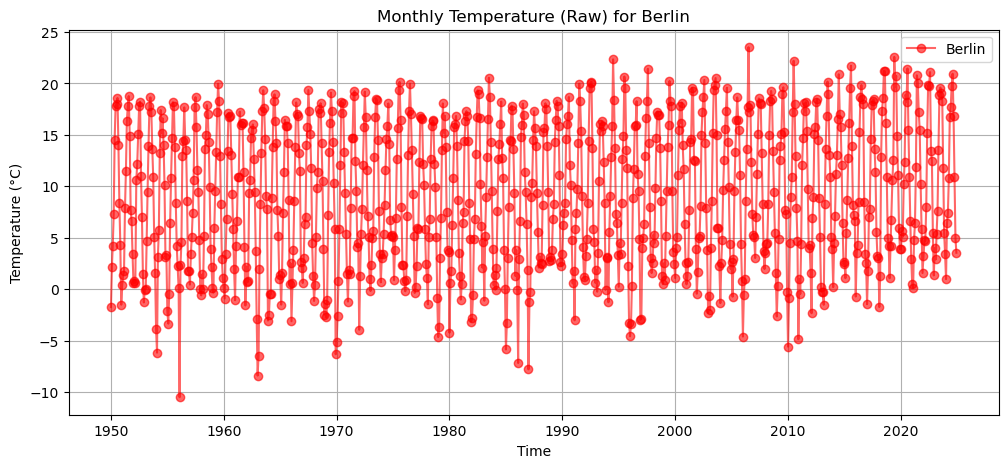

In [136]:
plt.figure(figsize=(12,5))

plt.plot(t2m_p["valid_time"], t2m_p, color="black", alpha=0.6, label="Paris",marker='o')
#plt.plot(t2m_b["valid_time"], t2m_b, color="red", alpha=0.6, label="Berlin")

plt.title("Monthly Temperature (Raw) for Paris")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()
############

plt.figure(figsize=(12,5))
plt.plot(t2m_b["valid_time"], t2m_b, color="red", alpha=0.6, label="Berlin",marker='o')

plt.title("Monthly Temperature (Raw) for Berlin")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()


# Yearly trends

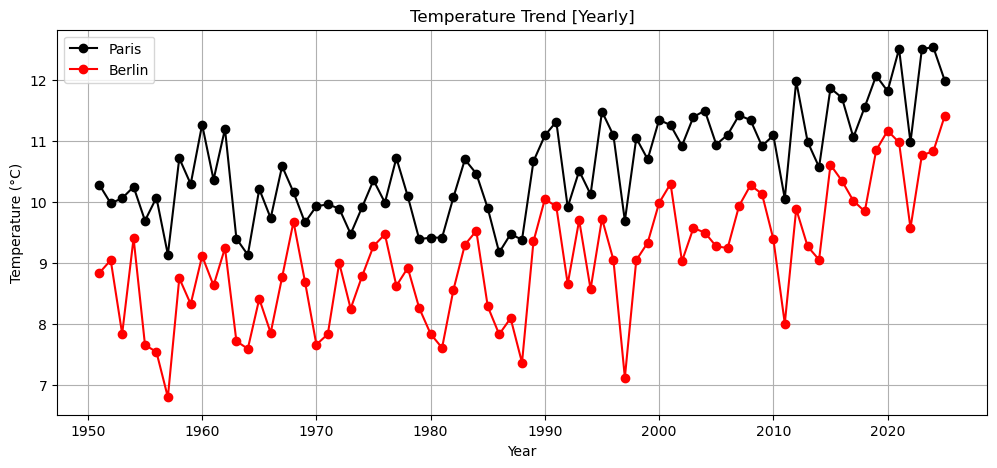

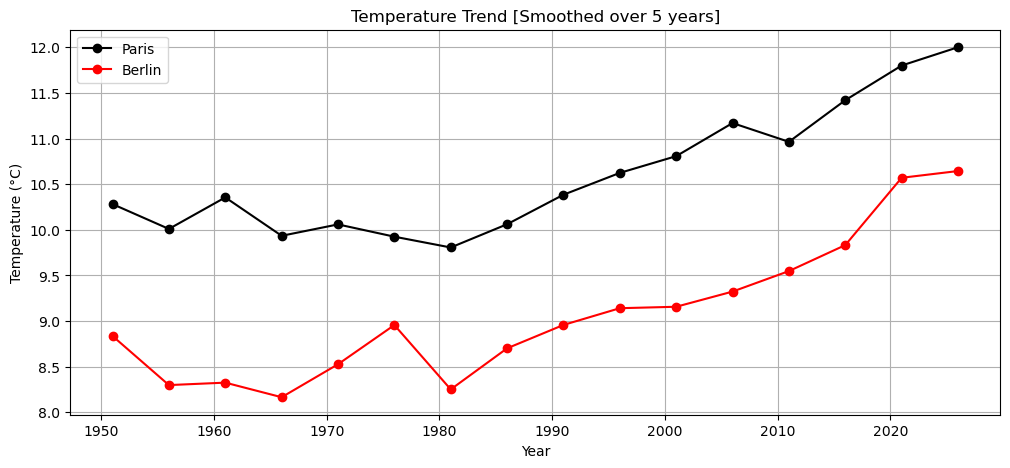

In [137]:
t2m_p_year = t2m_p.resample({"valid_time": "1YE"}).mean()
t2m_b_year = t2m_b.resample({"valid_time": "1YE"}).mean()

plt.figure(figsize=(12,5))

plt.plot(t2m_p_year["valid_time"], t2m_p_year, marker="o", color="black", label="Paris")
plt.plot(t2m_b_year["valid_time"], t2m_b_year, marker="o", color="red", label="Berlin")

plt.title("Temperature Trend [Yearly]")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()
#########################
t2m_p_year = t2m_p.resample({"valid_time": "5YE"}).mean()
t2m_b_year = t2m_b.resample({"valid_time": "5YE"}).mean()

plt.figure(figsize=(12,5))

plt.plot(t2m_p_year["valid_time"], t2m_p_year, marker="o", color="black", label="Paris")
plt.plot(t2m_b_year["valid_time"], t2m_b_year, marker="o", color="red", label="Berlin")

plt.title("Temperature Trend [Smoothed over 5 years]")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()

# Anomaly form baseline of 1950-1980 [Paris]

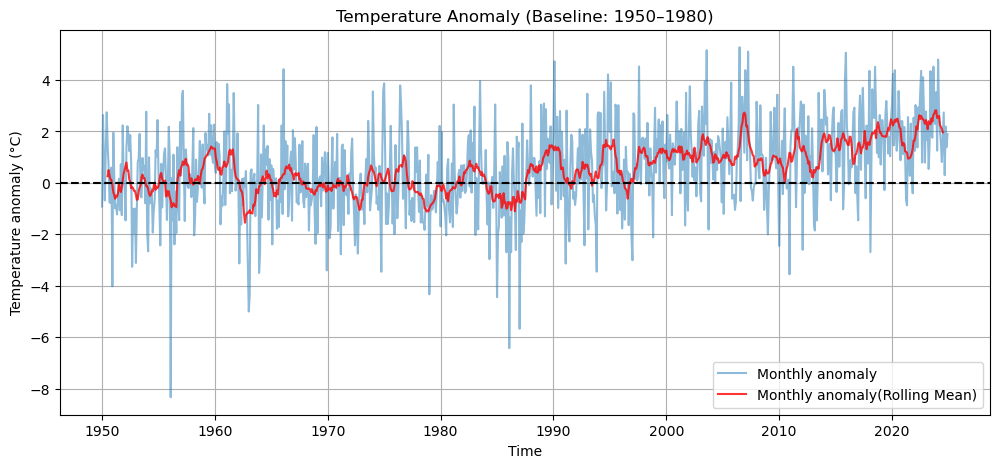

In [138]:
baseline_p = t2m_p.sel(valid_time=slice("1950", "1980"))
climatology_p = baseline_p.groupby("valid_time.month").mean()
anomaly_p = t2m_p.groupby("valid_time.month") - climatology_p
anomaly_smooth_p = anomaly_p.rolling(valid_time=12, center=True).mean()
### Plot
plt.figure(figsize=(12,5))
plt.plot(anomaly_p["valid_time"], anomaly_p, label="Monthly anomaly", alpha=0.5)
plt.plot(anomaly_smooth_p["valid_time"], anomaly_smooth_p, label="Monthly anomaly(Rolling Mean)", alpha=0.8,color='red')
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Time")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Temperature Anomaly (Baseline: 1950–1980)")
plt.legend()
plt.grid()

plt.show()

## Temperature anomaly smoothed over 1 year and 5 years

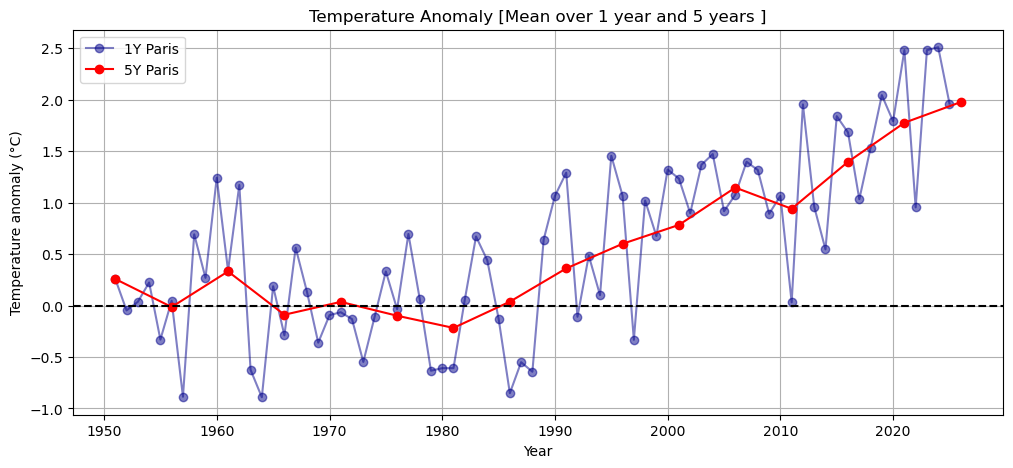

In [139]:
anomaly_5yearly = anomaly_p.resample(valid_time="5YE").mean()
anomaly_yearly = anomaly_p.resample(valid_time="1YE").mean()
plt.figure(figsize=(12,5))

plt.plot(anomaly_yearly["valid_time"], anomaly_yearly, marker="o",label="1Y Paris",color='darkblue',alpha=0.5)
plt.plot(anomaly_5yearly["valid_time"], anomaly_5yearly, marker="o",label="5Y Paris",color='red')
plt.axhline(0, color="black", linestyle="--")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Temperature Anomaly [Mean over 1 year and 5 years ]")
plt.grid()

plt.show()

# STL decomposition

## Period=12 months

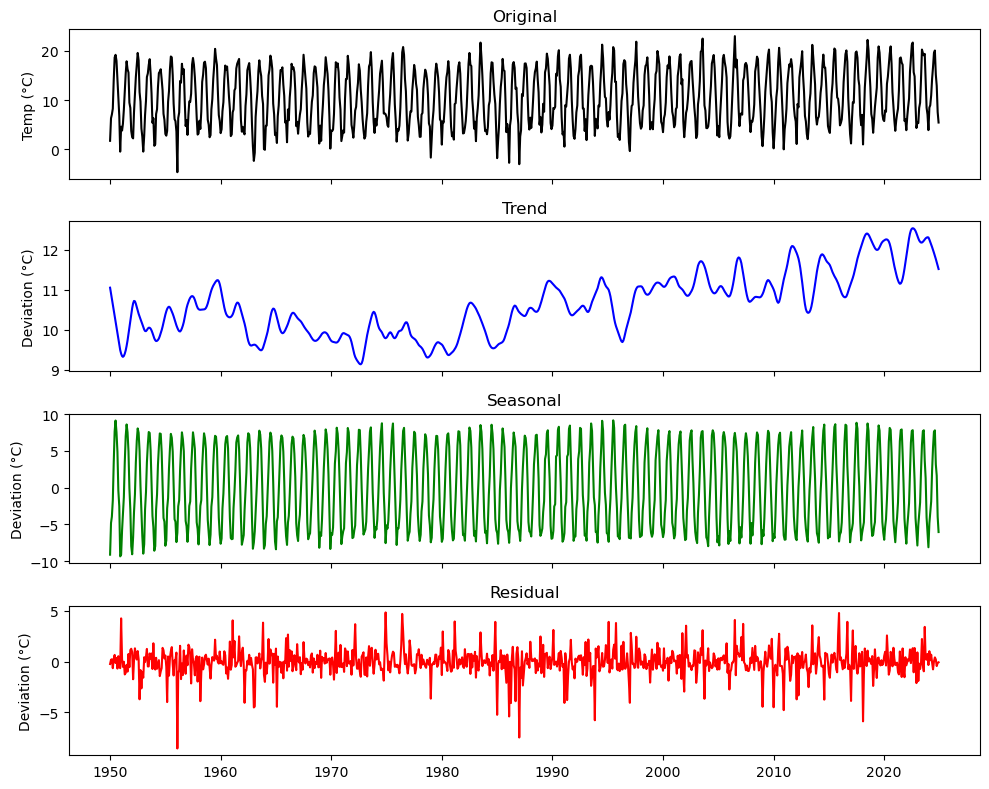

In [140]:
series = t2m_p.to_series().dropna()
series = series.sort_index()


stl_p = STL(series, period=12, robust=True)  # monthly data → 12
result = stl_p.fit()
fig, axes = plt.subplots(4, 1, figsize=(10,8), sharex=True)

axes[0].plot(series, color="black")
axes[0].set_title("Original")
axes[0].set_ylabel("Temp (°C)")

axes[1].plot(result.trend, color="blue")
axes[1].set_title("Trend")
axes[1].set_ylabel("Deviation (°C)")

axes[2].plot(result.seasonal, color="green")
axes[2].set_title("Seasonal")
axes[2].set_ylabel("Deviation (°C)")

axes[3].plot(result.resid, color="red")
axes[3].set_title("Residual")
axes[3].set_ylabel("Deviation (°C)")

plt.tight_layout()
plt.show()

## Period =24 months

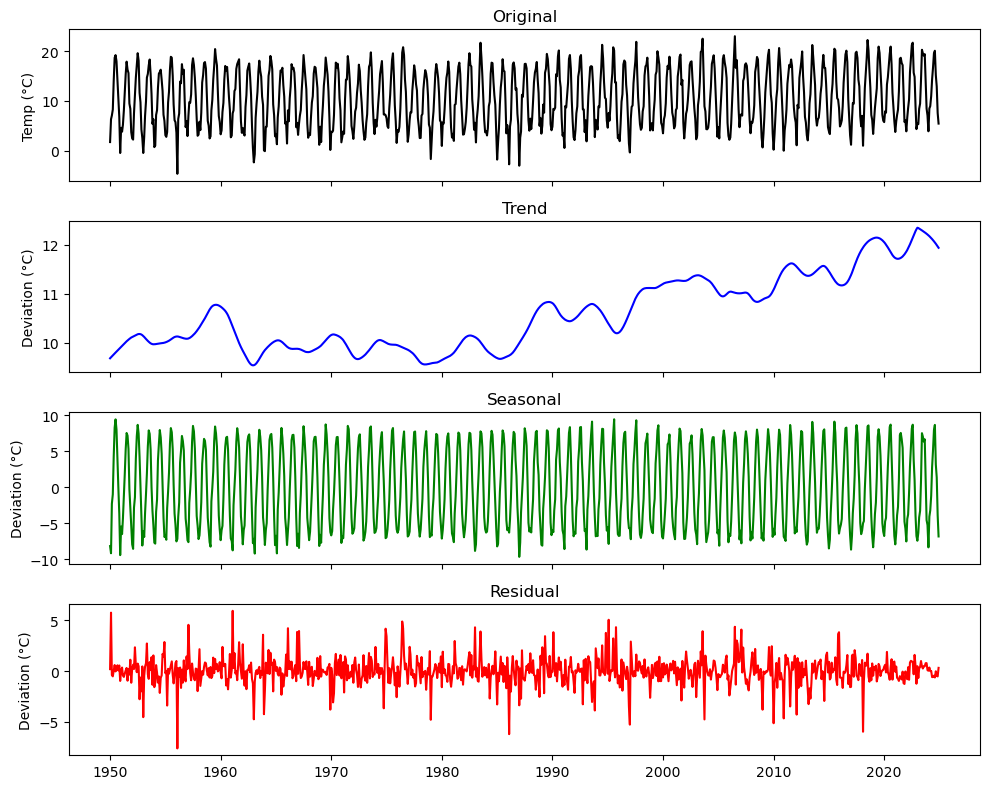

In [141]:
series = t2m_p.to_series().dropna()
series = series.sort_index()


stl_p = STL(series, period=24, robust=True)  # monthly data → 12
stl_result = stl_p.fit()
fig, axes = plt.subplots(4, 1, figsize=(10,8), sharex=True)

axes[0].plot(series, color="black")
axes[0].set_title("Original")
axes[0].set_ylabel("Temp (°C)")

axes[1].plot(stl_result.trend, color="blue")
axes[1].set_title("Trend")
axes[1].set_ylabel("Deviation (°C)")

axes[2].plot(stl_result.seasonal, color="green")
axes[2].set_title("Seasonal")
axes[2].set_ylabel("Deviation (°C)")

axes[3].plot(stl_result.resid, color="red")
axes[3].set_title("Residual")
axes[3].set_ylabel("Deviation (°C)")

plt.tight_layout()
plt.show()

# Trend analysis (linear or non-linear)

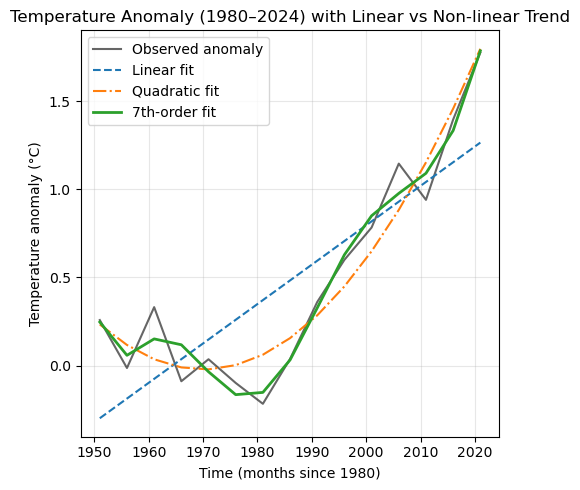

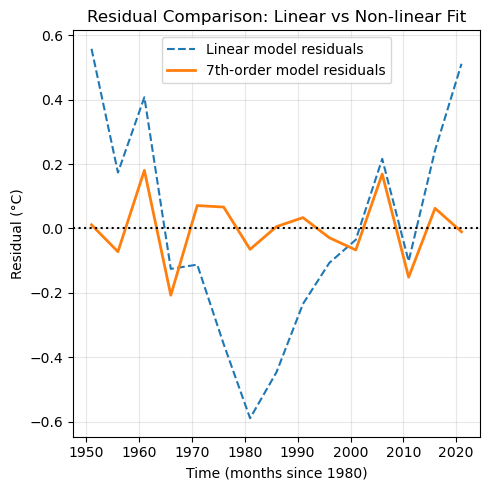

In [142]:
# We see an increase in temperature, after the baseline years. 
# Check if this trend is linear or non-linear by doing a polynomial fit

anomaly_after_1950= anomaly_5yearly.sel(valid_time=slice("1950-01-01", "2024-12-31"))
time_after_1950 = anomaly_after_1950["valid_time"]
t = np.arange(len(anomaly_after_1950))
coef_1o = np.polyfit(t, anomaly_after_1950, 1)  # linear fit
coef_2o = np.polyfit(t, anomaly_after_1950, 2)  # quadratic fit
N=7
coef_No = np.polyfit(t, anomaly_after_1950, N)  # cubic fit
y_fit_1o = np.polyval(coef_1o, t)
y_fit_2o = np.polyval(coef_2o, t)
y_fit_No = np.polyval(coef_No, t)

residuals_1o = anomaly_after_1950 - y_fit_1o
residuals_2o = anomaly_after_1950 - y_fit_2o
residuals_No = anomaly_after_1950 - y_fit_No

plt.figure(figsize=(5, 5))

plt.plot(time_after_1950,anomaly_after_1950, label='Observed anomaly', color='black', alpha=0.6)
plt.plot(time_after_1950,y_fit_1o, label='Linear fit', linestyle='--')
plt.plot(time_after_1950,y_fit_2o, label='Quadratic fit', linestyle='-.')
plt.plot(time_after_1950,y_fit_No, label=f'{N}th-order fit', linewidth=2)

plt.xlabel("Time (months since 1980)")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Temperature Anomaly (1980–2024) with Linear vs Non-linear Trend")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.plot(time_after_1950,residuals_1o, label="Linear model residuals", linestyle='--')
plt.plot(time_after_1950,residuals_No, label=f"{N}th-order model residuals", linewidth=2)

plt.axhline(0, linestyle=':', color='black')  # reference line

plt.xlabel("Time (months since 1980)")
plt.ylabel("Residual (°C)")
plt.title("Residual Comparison: Linear vs Non-linear Fit")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Compute the AIC and BIC criteria 

In [143]:


def compute_aic_bic(y, y_pred, k):
    n = len(y)
    rss = np.sum((y - y_pred)**2)
    
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    
    return aic, bic

degrees = [1, 2, 3, 4,6,7,8,9,10]  

results = {}

for d in degrees:
    coef = np.polyfit(t, anomaly_after_1950, d)
    y_fit = np.polyval(coef, t)
    
    k = d + 1  # number of parameters
    aic, bic = compute_aic_bic(anomaly_after_1950, y_fit, k)
    
    results[d] = (aic, bic)
for d, (aic, bic) in results.items():
    print(f"Degree {d}: AIC = {aic:.2f}, BIC = {bic:.2f}")

Degree 1: AIC = -29.09, BIC = -27.67
Degree 2: AIC = -49.07, BIC = -46.94
Degree 3: AIC = -48.11, BIC = -45.28
Degree 4: AIC = -47.01, BIC = -43.47
Degree 6: AIC = -51.71, BIC = -46.75
Degree 7: AIC = -52.48, BIC = -46.82
Degree 8: AIC = -50.48, BIC = -44.11
Degree 9: AIC = -51.78, BIC = -44.70
Degree 10: AIC = -49.96, BIC = -42.17


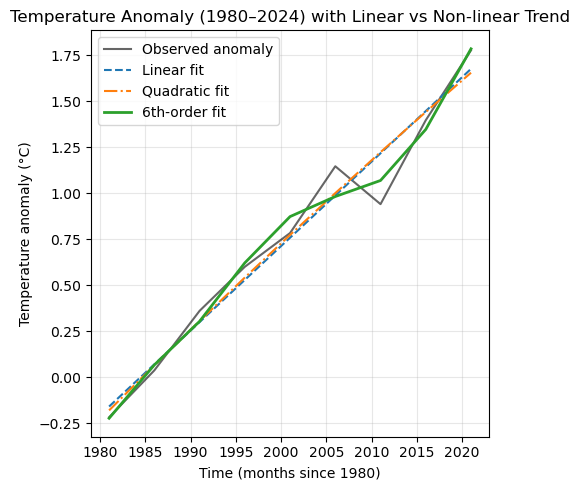

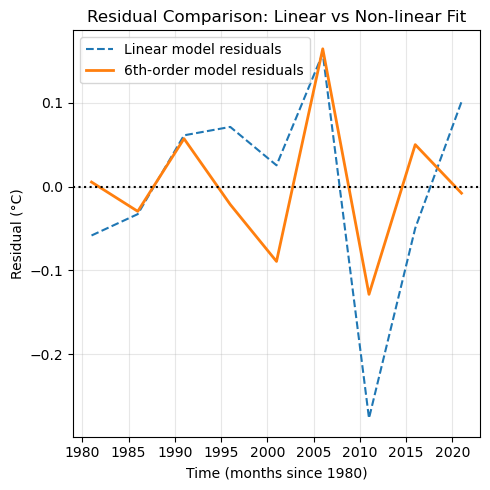

In [144]:
# We see an increase in temperature, after the baseline years. 
# Check if this trend is linear or non-linear by doing a polynomial fit

anomaly_after_1980= anomaly_5yearly.sel(valid_time=slice("1980-01-01", "2024-12-31"))
time_after_1980 = anomaly_after_1980["valid_time"]
t = np.arange(len(anomaly_after_1980))
coef_1o = np.polyfit(t, anomaly_after_1980, 1)  # linear fit
coef_2o = np.polyfit(t, anomaly_after_1980, 2)  # quadratic fit
N=6
coef_No = np.polyfit(t, anomaly_after_1980, N)  # cubic fit
y_fit_1o = np.polyval(coef_1o, t)
y_fit_2o = np.polyval(coef_2o, t)
y_fit_No = np.polyval(coef_No, t)

residuals_1o = anomaly_after_1980 - y_fit_1o
residuals_2o = anomaly_after_1980 - y_fit_2o
residuals_No = anomaly_after_1980 - y_fit_No

plt.figure(figsize=(5, 5))

plt.plot(time_after_1980,anomaly_after_1980, label='Observed anomaly', color='black', alpha=0.6)
plt.plot(time_after_1980,y_fit_1o, label='Linear fit', linestyle='--')
plt.plot(time_after_1980,y_fit_2o, label='Quadratic fit', linestyle='-.')
plt.plot(time_after_1980,y_fit_No, label=f'{N}th-order fit', linewidth=2)

plt.xlabel("Time (months since 1980)")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Temperature Anomaly (1980–2024) with Linear vs Non-linear Trend")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.plot(time_after_1980,residuals_1o, label="Linear model residuals", linestyle='--')
plt.plot(time_after_1980,residuals_No, label=f"{N}th-order model residuals", linewidth=2)

plt.axhline(0, linestyle=':', color='black')  # reference line

plt.xlabel("Time (months since 1980)")
plt.ylabel("Residual (°C)")
plt.title("Residual Comparison: Linear vs Non-linear Fit")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [126]:
results_1980={}
degrees = [1, 2, 3, 4,6,7,8]  
for d in degrees:
    coef = np.polyfit(t, anomaly_after_1980, d)
    y_fit = np.polyval(coef, t)
    
    k = d + 1  # number of parameters
    aic, bic = compute_aic_bic(anomaly_after_1980, y_fit, k)
    results_1980[d] = (aic, bic)
for d, (aic, bic) in results_1980.items():
    print(f"Degree {d}: AIC = {aic:.2f}, BIC = {bic:.2f}")

Degree 1: AIC = -34.27, BIC = -33.87
Degree 2: AIC = -32.37, BIC = -31.78
Degree 3: AIC = -33.36, BIC = -32.57
Degree 4: AIC = -34.40, BIC = -33.42
Degree 6: AIC = -31.29, BIC = -29.91
Degree 7: AIC = -38.56, BIC = -36.99
Degree 8: AIC = -431.44, BIC = -429.67


# Stationarity Analysis

In [128]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
stl_resid = stl_result.resid.dropna()
resid_diff = stl_resid.diff().dropna()
adf_stat, adf_p, _, _, _, _ = adfuller(resid_diff)

print("ADF Statistic:", adf_stat)
print("ADF p-value:", adf_p)

kpss_stat, kpss_p, _, _ = kpss(resid_diff,regression='ct') 

print("KPSS Statistic:", kpss_stat)
print("KPSS p-value:", kpss_p)

ADF Statistic: -10.479566887516755
ADF p-value: 1.223685399874846e-18
KPSS Statistic: 0.24301221707259824
KPSS p-value: 0.01


/var/folders/0k/l3y6c1715lx_w_md138wjbrw2_cgrs/T/ipykernel_63340/2550073879.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(resid_diff,regression='ct')
